In [1]:
!pip install "cdsapi>=0.7.7" xarray dask netcdf4 rioxarray pandas matplotlib

In [2]:
from pathlib import Path

Path("./data_heavy").mkdir(exist_ok=True)
Path("./scripts").mkdir(exist_ok=True)

print("Carpeta data_heavy:", Path("./data_heavy").resolve())
print("Carpeta scripts:", Path("./scripts").resolve())

Carpeta data_heavy: /home/rstudio/work/PRACTICA_6/data_heavy
Carpeta scripts: /home/rstudio/work/PRACTICA_6/scripts


In [3]:
from pathlib import Path

cdsapirc = Path.home() / ".cdsapirc"

print("Ruta esperada del archivo .cdsapirc:")
print(cdsapirc)

print("\n¿Existe?")
print(cdsapirc.exists())

Ruta esperada del archivo .cdsapirc:
/root/.cdsapirc

¿Existe?
False


In [4]:
from pathlib import Path
from getpass import getpass
import os

token = getpass("Pega aquí tu API key de Copernicus: ")

cdsapirc = Path.home() / ".cdsapirc"

contenido = f"""url: https://cds.climate.copernicus.eu/api
key: {token}
"""

cdsapirc.write_text(contenido)
os.chmod(cdsapirc, 0o600)

print("Archivo .cdsapirc creado en:")
print(cdsapirc)

Pega aquí tu API key de Copernicus:  ········


Archivo .cdsapirc creado en:
/root/.cdsapirc


In [5]:
from pathlib import Path

cdsapirc = Path.home() / ".cdsapirc"

print("Ruta:")
print(cdsapirc)

print("\n¿Existe?")
print(cdsapirc.exists())

if cdsapirc.exists():
    print("\nConfiguración detectada correctamente.")
    print("url: https://cds.climate.copernicus.eu/api")
    print("key: ********")

Ruta:
/root/.cdsapirc

¿Existe?
True

Configuración detectada correctamente.
url: https://cds.climate.copernicus.eu/api
key: ********


In [6]:
%run scripts/descargar_era5.py

2026-04-26 03:16:32,009 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-26 03:16:32,010 INFO Request ID is ee40e31b-25e8-47d2-bd55-c96469b76f9e
2026-04-26 03:16:32,219 INFO status has been updated to accepted
2026-04-26 03:16:46,479 INFO status has been updated to running
2026-04-26 03:17:49,002 INFO status has been updated to successful


4ee9be3d7cd0114d8e6d4dfd7d603be9.nc:   0%|          | 0.00/185k [00:00<?, ?B/s]

Descarga finalizada: ./data_heavy/era5_bogota_t2m_2020_01.nc


In [7]:
from pathlib import Path

archivo = Path("./data_heavy/era5_land_meta_t2m_2024_01.nc")

print("¿Existe el archivo?")
print(archivo.exists())

if archivo.exists():
    print("Tamaño en MB:")
    print(round(archivo.stat().st_size / 1024 / 1024, 2))

¿Existe el archivo?
False


In [8]:
from pathlib import Path

print("Archivos NetCDF encontrados en data_heavy:")

for archivo in Path("./data_heavy").glob("*.nc"):
    print("-", archivo.name)

Archivos NetCDF encontrados en data_heavy:
- download5Dcolombia.nc
- era5_bogota_t2m_2020_01.nc
- goodland_10u_1.nc
- t_diaria_bogota_9377.nc


In [9]:
%%writefile scripts/descargar_era5.py

import cdsapi
from pathlib import Path

# ============================================================
# Descarga ERA5-Land desde Copernicus CDS
# Zona: Departamento del Meta, Colombia
# Variable: Temperatura a 2 metros
# Periodo: Enero de 2024
# Formato: NetCDF
# ============================================================

Path("./data_heavy").mkdir(exist_ok=True)

dataset = "reanalysis-era5-land"

request = {
    "variable": ["2m_temperature"],
    "year": "2024",
    "month": "01",
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",

    # Departamento del Meta aproximadamente
    # Orden: [Norte, Oeste, Sur, Este]
    "area": [5, -75, 1.5, -68.5]
}

salida = "./data_heavy/era5_land_meta_t2m_2024_01.nc"

client = cdsapi.Client()
client.retrieve(dataset, request).download(salida)

print(f"Descarga finalizada: {salida}")

Overwriting scripts/descargar_era5.py


In [10]:
%run scripts/descargar_era5.py

2026-04-26 03:20:13,277 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-04-26 03:20:13,277 INFO Request ID is a2435faf-2748-42e8-9013-1a167e41f5b1
2026-04-26 03:20:13,491 INFO status has been updated to accepted
2026-04-26 03:20:36,416 INFO status has been updated to running
2026-04-26 03:23:08,579 INFO status has been updated to successful


fdc76fe25d25cd064b6ce0037c299ca3.nc:   0%|          | 0.00/2.72M [00:00<?, ?B/s]

Descarga finalizada: ./data_heavy/era5_land_meta_t2m_2024_01.nc


In [12]:
import xarray as xr

archivo_nc = "./data_heavy/era5_land_meta_t2m_2024_01.nc"

ds = xr.open_dataset(archivo_nc, chunks="auto")

print(ds)
print("\nVariables:")
print(list(ds.data_vars))
print("\nDimensiones:")
print(ds.dims)
print("\nCoordenadas:")
print(ds.coords)

<xarray.Dataset> Size: 7MB
Dimensions:     (valid_time: 744, latitude: 36, longitude: 66)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23:...
  * latitude    (latitude) float64 288B 5.0 4.9 4.8 4.7 4.6 ... 1.8 1.7 1.6 1.5
  * longitude   (longitude) float64 528B -75.0 -74.9 -74.8 ... -68.7 -68.6 -68.5
    number      int64 8B ...
    expver      (valid_time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 7MB dask.array<chunksize=(744, 36, 66), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-26T03:22 GRIB to CDM+CF via cfgrib-0.9.1...

Variables:
['t2m']

Dimensiones:
FrozenMappingWarningOnV

In [13]:
import xarray as xr
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Archivo descargado para el Meta
archivo_nc = "./data_heavy/era5_land_meta_t2m_2024_01.nc"

# Abrir con evaluación perezosa
ds = xr.open_dataset(
    archivo_nc,
    chunks={"valid_time": 24}
)

# Asignar CRS geográfico
ds = ds.rio.write_crs("EPSG:4326")

# Definir dimensiones espaciales
ds = ds.rio.set_spatial_dims(
    x_dim="longitude",
    y_dim="latitude"
)

print("=== DATASET ===")
print(ds)

print("\n=== CRS ===")
print(ds.rio.crs)

print("\n=== VARIABLES ===")
print(list(ds.data_vars))

print("\n=== DIMENSIONES ===")
print(ds.dims)

=== DATASET ===
<xarray.Dataset> Size: 7MB
Dimensions:      (valid_time: 744, latitude: 36, longitude: 66)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23...
  * latitude     (latitude) float64 288B 5.0 4.9 4.8 4.7 4.6 ... 1.8 1.7 1.6 1.5
  * longitude    (longitude) float64 528B -75.0 -74.9 -74.8 ... -68.6 -68.5
    number       int64 8B ...
    expver       (valid_time) <U4 12kB dask.array<chunksize=(24,), meta=np.ndarray>
    spatial_ref  int64 8B 0
Data variables:
    t2m          (valid_time, latitude, longitude) float32 7MB dask.array<chunksize=(24, 36, 66), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-26T03:22 GRIB to CDM+CF via cfgrib-0.9.1...

=== CRS ===
EP

/tmp/ipykernel_1330/382776412.py:11: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 24. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


In [14]:
# Variable principal
t_kelvin = ds["t2m"]

# Conversión Kelvin a Celsius
t_celsius = t_kelvin - 273.15

# Actualizar metadatos
t_celsius.attrs["units"] = "°C"
t_celsius.attrs["long_name"] = "Temperatura del aire a 2 metros en grados Celsius"

print("=== TEMPERATURA EN CELSIUS ===")
print(t_celsius)

=== TEMPERATURA EN CELSIUS ===
<xarray.DataArray 't2m' (valid_time: 744, latitude: 36, longitude: 66)> Size: 7MB
dask.array<sub, shape=(744, 36, 66), dtype=float32, chunksize=(24, 36, 66), chunktype=numpy.ndarray>
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23...
  * latitude     (latitude) float64 288B 5.0 4.9 4.8 4.7 4.6 ... 1.8 1.7 1.6 1.5
  * longitude    (longitude) float64 528B -75.0 -74.9 -74.8 ... -68.6 -68.5
    number       int64 8B ...
    expver       (valid_time) <U4 12kB dask.array<chunksize=(24,), meta=np.ndarray>
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2376
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNum

In [15]:
# Diferencia entre los dos primeros registros temporales
delta_t = t_celsius.valid_time.diff(dim="valid_time")[0].values

# Convertir a horas
horas_paso = delta_t / pd.Timedelta("1 hour")

print(f"Resolución temporal detectada: {horas_paso} horas")

Resolución temporal detectada: 1.0 horas


In [16]:
# Agrupar de horario a diario
t_diaria = t_celsius.resample(valid_time="1D").mean()

# Actualizar metadatos
t_diaria.attrs["units"] = "°C"
t_diaria.attrs["long_name"] = "Temperatura media diaria a 2 metros"

print("=== TEMPERATURA MEDIA DIARIA ===")
print(t_diaria)

=== TEMPERATURA MEDIA DIARIA ===
<xarray.DataArray 't2m' (valid_time: 31, latitude: 36, longitude: 66)> Size: 295kB
dask.array<stack, shape=(31, 36, 66), dtype=float32, chunksize=(1, 36, 66), chunktype=numpy.ndarray>
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 248B 2024-01-01 ... 2024-01-31
  * latitude     (latitude) float64 288B 5.0 4.9 4.8 4.7 4.6 ... 1.8 1.7 1.6 1.5
  * longitude    (longitude) float64 528B -75.0 -74.9 -74.8 ... -68.6 -68.5
    number       int64 8B ...
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2376
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    lon

In [17]:
# Máxima mensual de las medias diarias
t_max_mensual = t_diaria.max(dim="valid_time")

# Actualizar metadatos
t_max_mensual.attrs["units"] = "°C"
t_max_mensual.attrs["long_name"] = "Máxima mensual de la temperatura media diaria"

print("=== MÁXIMA MENSUAL ===")
print(t_max_mensual)

=== MÁXIMA MENSUAL ===
<xarray.DataArray 't2m' (latitude: 36, longitude: 66)> Size: 10kB
dask.array<_nanmax_skip-aggregate, shape=(36, 66), dtype=float32, chunksize=(36, 66), chunktype=numpy.ndarray>
Coordinates:
  * latitude     (latitude) float64 288B 5.0 4.9 4.8 4.7 4.6 ... 1.8 1.7 1.6 1.5
  * longitude    (longitude) float64 528B -75.0 -74.9 -74.8 ... -68.6 -68.5
    number       int64 8B ...
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2376
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Máxima mensual de la temperatur...
    units:         

In [18]:
# Fecha en la que ocurrió la máxima mensual en cada píxel
fecha_max_mensual = t_diaria.idxmax(dim="valid_time")

# Actualizar metadatos
fecha_max_mensual.attrs["long_name"] = "Fecha de ocurrencia de la máxima mensual"

print("=== FECHA DE OCURRENCIA DE LA MÁXIMA ===")
print(fecha_max_mensual)

=== FECHA DE OCURRENCIA DE LA MÁXIMA ===
<xarray.DataArray 'valid_time' (latitude: 36, longitude: 66)> Size: 19kB
dask.array<where, shape=(36, 66), dtype=datetime64[ns], chunksize=(36, 66), chunktype=numpy.ndarray>
Coordinates:
  * latitude     (latitude) float64 288B 5.0 4.9 4.8 4.7 4.6 ... 1.8 1.7 1.6 1.5
  * longitude    (longitude) float64 528B -75.0 -74.9 -74.8 ... -68.6 -68.5
    number       int64 8B 0
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2376
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Fecha de ocurrencia de la máxim...
    un

In [22]:
import xarray as xr
import numpy as np
from pathlib import Path

# ============================================================
# Dataset final robusto para exportar a NetCDF
# ============================================================

# 1. Máxima mensual de la temperatura media diaria
t_max_mensual = t_diaria.max(dim="valid_time")

# Limpiar coordenadas adicionales y convertir a float32
t_max_mensual = t_max_mensual.reset_coords(drop=True)
t_max_mensual = t_max_mensual.astype("float32")

t_max_mensual.attrs["units"] = "°C"
t_max_mensual.attrs["long_name"] = "Máxima mensual de la temperatura media diaria"

# 2. Fecha de ocurrencia de la máxima mensual
fecha_max_mensual = t_diaria.idxmax(dim="valid_time")

# Materializar porque ya es una matriz pequeña
fecha_max_mensual = fecha_max_mensual.compute()

# Convertir fechas a texto tipo YYYY-MM-DD
fechas_str = fecha_max_mensual.values.astype("datetime64[D]").astype(str)

# Convertir de YYYY-MM-DD a entero YYYYMMDD
fecha_yyyymmdd = np.char.replace(fechas_str, "-", "").astype("int32")

# Crear DataArray con la fecha codificada
fecha_max_mensual_yyyymmdd = xr.DataArray(
    fecha_yyyymmdd,
    coords={
        "latitude": fecha_max_mensual["latitude"],
        "longitude": fecha_max_mensual["longitude"]
    },
    dims=("latitude", "longitude"),
    name="fecha_t2m_max_mensual_yyyymmdd"
)

fecha_max_mensual_yyyymmdd.attrs["long_name"] = "Fecha de ocurrencia de la máxima mensual"
fecha_max_mensual_yyyymmdd.attrs["format"] = "AAAAMMDD"
fecha_max_mensual_yyyymmdd.attrs["description"] = "Fecha codificada como entero. Ejemplo: 20240127"

# 3. Construir dataset final
ds_salida = xr.Dataset(
    {
        "t2m_max_mensual_celsius": t_max_mensual,
        "fecha_t2m_max_mensual_yyyymmdd": fecha_max_mensual_yyyymmdd
    }
)

# 4. Asignar CRS
ds_salida = ds_salida.rio.write_crs("EPSG:4326")
ds_salida = ds_salida.rio.set_spatial_dims(
    x_dim="longitude",
    y_dim="latitude"
)

print("=== DATASET FINAL ===")
print(ds_salida)

# 5. Exportar a NetCDF
salida = Path("./data_heavy/mi_zona_procesada.nc")

# Si ya existe, eliminarlo para evitar conflictos
if salida.exists():
    salida.unlink()

ds_salida.to_netcdf(
    salida,
    engine="netcdf4"
)

print(f"Archivo exportado correctamente: {salida}")

=== DATASET FINAL ===
<xarray.Dataset> Size: 20kB
Dimensions:                         (latitude: 36, longitude: 66)
Coordinates:
  * latitude                        (latitude) float64 288B 5.0 4.9 ... 1.6 1.5
  * longitude                       (longitude) float64 528B -75.0 ... -68.5
    spatial_ref                     int64 8B 0
Data variables:
    t2m_max_mensual_celsius         (latitude, longitude) float32 10kB dask.array<chunksize=(36, 66), meta=np.ndarray>
    fecha_t2m_max_mensual_yyyymmdd  (latitude, longitude) int32 10kB 20240123...
Archivo exportado correctamente: data_heavy/mi_zona_procesada.nc


In [23]:
import xarray as xr
from pathlib import Path

salida = Path("./data_heavy/mi_zona_procesada.nc")

print("¿Existe el archivo?")
print(salida.exists())

if salida.exists():
    print("Tamaño en MB:")
    print(round(salida.stat().st_size / 1024 / 1024, 2))

    ds_verificacion = xr.open_dataset(salida)
    print(ds_verificacion)

¿Existe el archivo?
True
Tamaño en MB:
0.04
<xarray.Dataset> Size: 20kB
Dimensions:                         (latitude: 36, longitude: 66)
Coordinates:
  * latitude                        (latitude) float64 288B 5.0 4.9 ... 1.6 1.5
  * longitude                       (longitude) float64 528B -75.0 ... -68.5
Data variables:
    t2m_max_mensual_celsius         (latitude, longitude) float32 10kB ...
    fecha_t2m_max_mensual_yyyymmdd  (latitude, longitude) int32 10kB ...
    spatial_ref                     int64 8B ...


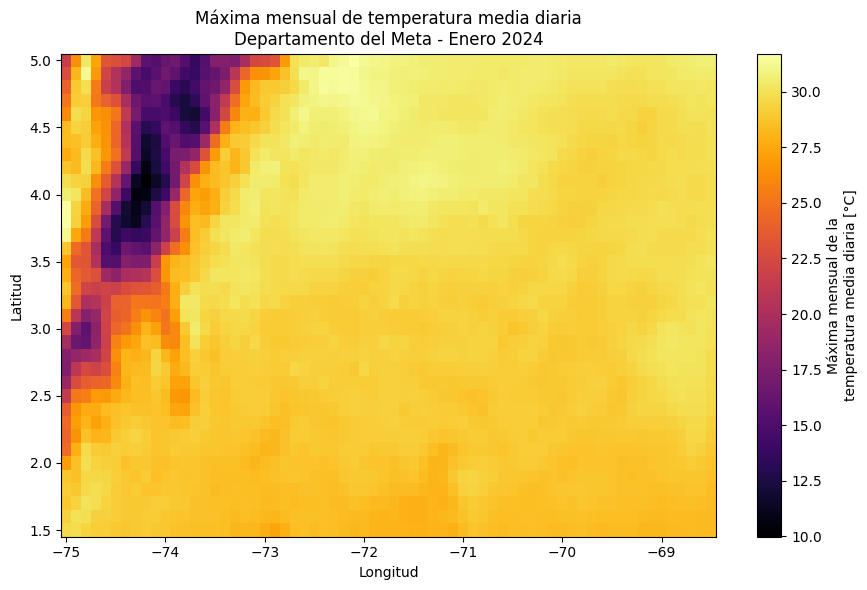

In [24]:
import xarray as xr
import matplotlib.pyplot as plt

# Abrir archivo procesado
ds_final = xr.open_dataset("./data_heavy/mi_zona_procesada.nc")

# Mapa de máxima mensual
plt.figure(figsize=(9, 6))

ds_final["t2m_max_mensual_celsius"].plot(cmap="inferno")

plt.title("Máxima mensual de temperatura media diaria\nDepartamento del Meta - Enero 2024")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

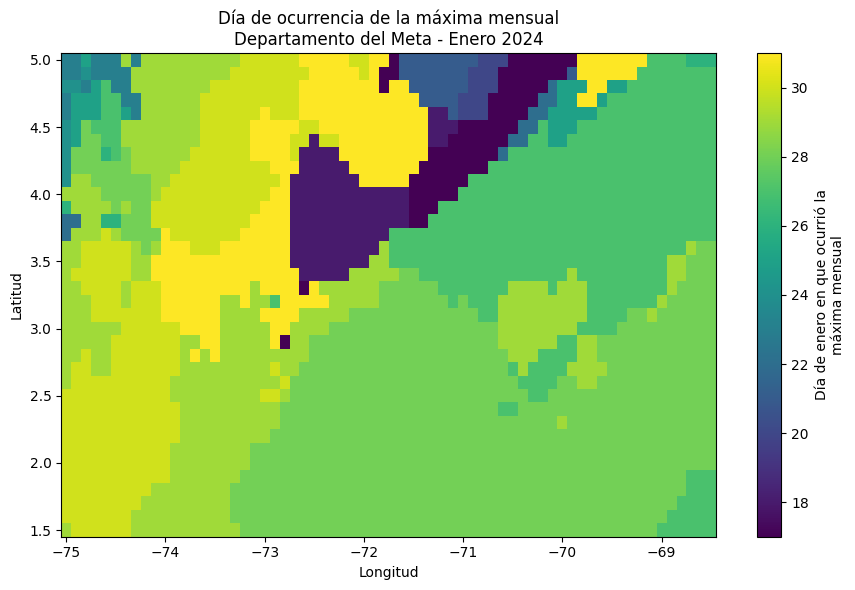

In [25]:
# Extraer la fecha codificada
fecha_codificada = ds_final["fecha_t2m_max_mensual_yyyymmdd"]

# Extraer solo el día del mes
dia_maxima = fecha_codificada % 100

dia_maxima.attrs["long_name"] = "Día de enero en que ocurrió la máxima mensual"

plt.figure(figsize=(9, 6))

dia_maxima.plot(cmap="viridis")

plt.title("Día de ocurrencia de la máxima mensual\nDepartamento del Meta - Enero 2024")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

In [26]:
tmax = ds_final["t2m_max_mensual_celsius"]

print("=== Estadísticas de la máxima mensual ===")
print("Temperatura mínima del mapa:", float(tmax.min().values), "°C")
print("Temperatura máxima del mapa:", float(tmax.max().values), "°C")
print("Temperatura media del mapa:", float(tmax.mean().values), "°C")

=== Estadísticas de la máxima mensual ===
Temperatura mínima del mapa: 9.977519035339355 °C
Temperatura máxima del mapa: 31.717269897460938 °C
Temperatura media del mapa: 28.189735412597656 °C


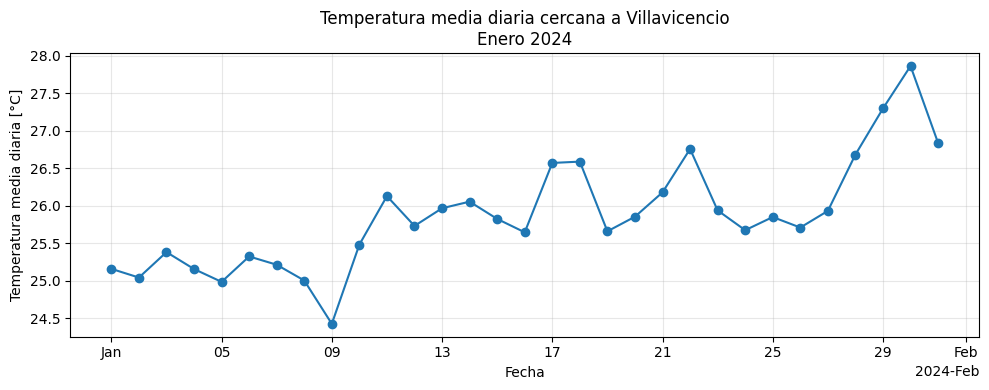

In [27]:
# Coordenadas aproximadas de Villavicencio
serie_villavicencio = t_diaria.sel(
    latitude=4.15,
    longitude=-73.63,
    method="nearest"
)

plt.figure(figsize=(10, 4))

serie_villavicencio.plot(marker="o")

plt.title("Temperatura media diaria cercana a Villavicencio\nEnero 2024")
plt.ylabel("Temperatura media diaria [°C]")
plt.xlabel("Fecha")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
from pathlib import Path

Path("./figures").mkdir(exist_ok=True)

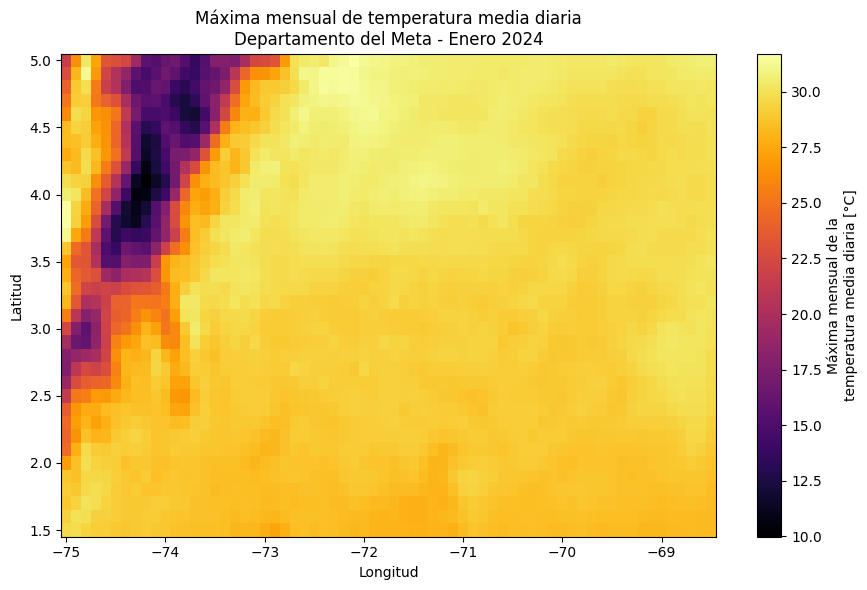

In [29]:
plt.figure(figsize=(9, 6))

ds_final["t2m_max_mensual_celsius"].plot(cmap="inferno")

plt.title("Máxima mensual de temperatura media diaria\nDepartamento del Meta - Enero 2024")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()

plt.savefig("./figures/mapa_tmax_mensual_meta.png", dpi=300)
plt.show()

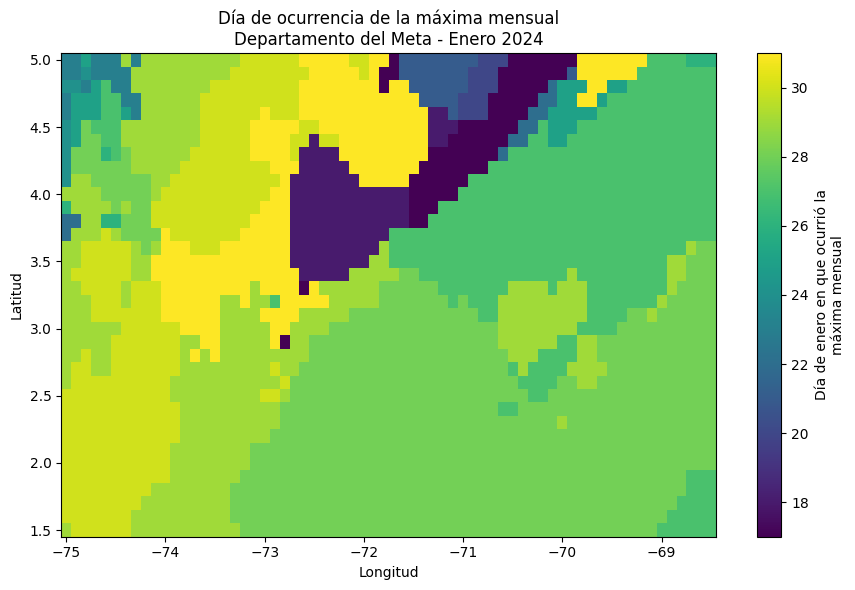

In [30]:
plt.figure(figsize=(9, 6))

dia_maxima.plot(cmap="viridis")

plt.title("Día de ocurrencia de la máxima mensual\nDepartamento del Meta - Enero 2024")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()

plt.savefig("./figures/mapa_dia_tmax_meta.png", dpi=300)
plt.show()

In [31]:
%%writefile .gitignore

data_heavy/
.ipynb_checkpoints/
__pycache__/
*.nc
*.zip
*.grib
*.idx
*.cdsapirc

Writing .gitignore
